Usando dispositivo: cuda


/usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch  500 | Loss PDE: 8.064e-05 | Loss IC: 3.441e-05
Epoch 1000 | Loss PDE: 4.829e-05 | Loss IC: 1.949e-05
Epoch 1500 | Loss PDE: 3.292e-05 | Loss IC: 1.382e-05
Epoch 2000 | Loss PDE: 2.396e-05 | Loss IC: 1.066e-05
Epoch 2500 | Loss PDE: 1.825e-05 | Loss IC: 9.044e-06
Epoch 3000 | Loss PDE: 1.357e-05 | Loss IC: 2.736e-05
Epoch 3500 | Loss PDE: 1.006e-05 | Loss IC: 6.161e-06
Epoch 4000 | Loss PDE: 7.961e-06 | Loss IC: 5.532e-06
Epoch 4500 | Loss PDE: 6.993e-06 | Loss IC: 5.431e-06
Epoch 5000 | Loss PDE: 5.172e-06 | Loss IC: 5.016e-06


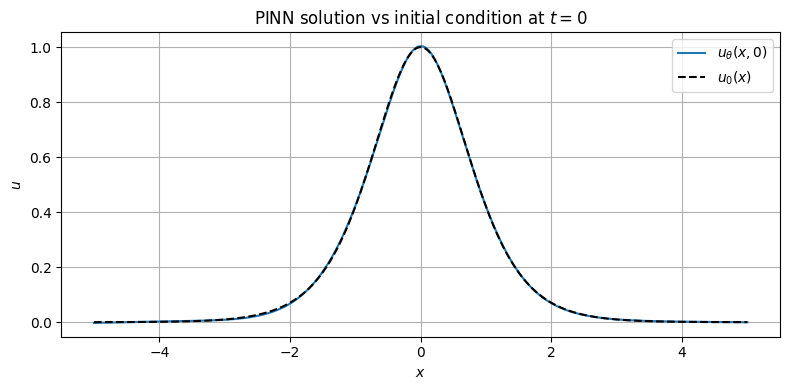

In [1]:
# ===============================================
# 1. Imports y configuración
# ===============================================
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# ===============================================
# 2. Red neuronal (PINN)
# ===============================================
class MLP(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(len(layers)-2):
            self.net.append(nn.Linear(layers[i], layers[i+1]))
            self.net.append(nn.Tanh())
        self.net.append(nn.Linear(layers[-2], layers[-1]))

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

# ===============================================
# 3. Condición inicial y dominio
# ===============================================
def initial_condition(x):
    return 1.0 / np.cosh(x)**2  # Solitón clásico

# Dominio de entrenamiento
x_vals = np.linspace(-5, 5, 256)
t_vals = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_vals, t_vals)

x_r = torch.tensor(X.flatten(), dtype=torch.float32).view(-1, 1).to(device)
t_r = torch.tensor(T.flatten(), dtype=torch.float32).view(-1, 1).to(device)

# Datos para condición inicial
x_ic = torch.tensor(x_vals, dtype=torch.float32).view(-1, 1).to(device)
t_ic = torch.zeros_like(x_ic).to(device)
u0 = torch.tensor(initial_condition(x_vals), dtype=torch.float32).view(-1, 1).to(device)

# ===============================================
# 4. Residuo físico de la gKdV
# ===============================================
alpha, nu, beta = 1.0, 3.0, 0.1  # parámetros de la ecuación

def gkdv_residual(model, x, t, alpha, nu, beta):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    return u_t + alpha * u**nu * u_x + beta * u_xxx

# ===============================================
# 5. Entrenamiento
# ===============================================
model = MLP([2, 128, 128, 128, 1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1, 5001):
    optimizer.zero_grad()

    # Residuo de la PDE
    res = gkdv_residual(model, x_r, t_r, alpha, nu, beta)
    loss_pde = (res**2).mean()

    # Condición inicial
    u_pred0 = model(x_ic, t_ic)
    loss_ic = ((u_pred0 - u0)**2).mean()

    # Total loss
    loss = loss_pde + loss_ic
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss PDE: {loss_pde.item():.3e} | Loss IC: {loss_ic.item():.3e}")

# ===============================================
# 6. Visualización de la solución en t = 0
# ===============================================
x_plot = np.linspace(-5, 5, 400)
t_plot = np.zeros_like(x_plot)

x_tensor = torch.tensor(x_plot, dtype=torch.float32).view(-1, 1).to(device)
t_tensor = torch.tensor(t_plot, dtype=torch.float32).view(-1, 1).to(device)

with torch.no_grad():
    u_pred = model(x_tensor, t_tensor).cpu().numpy()

plt.figure(figsize=(8, 4))
plt.plot(x_plot, u_pred, label='$u_\\theta(x, 0)$')
plt.plot(x_plot, initial_condition(x_plot), 'k--', label='$u_0(x)$')
plt.xlabel('$x$')
plt.ylabel('$u$')
plt.title('PINN solution vs initial condition at $t=0$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


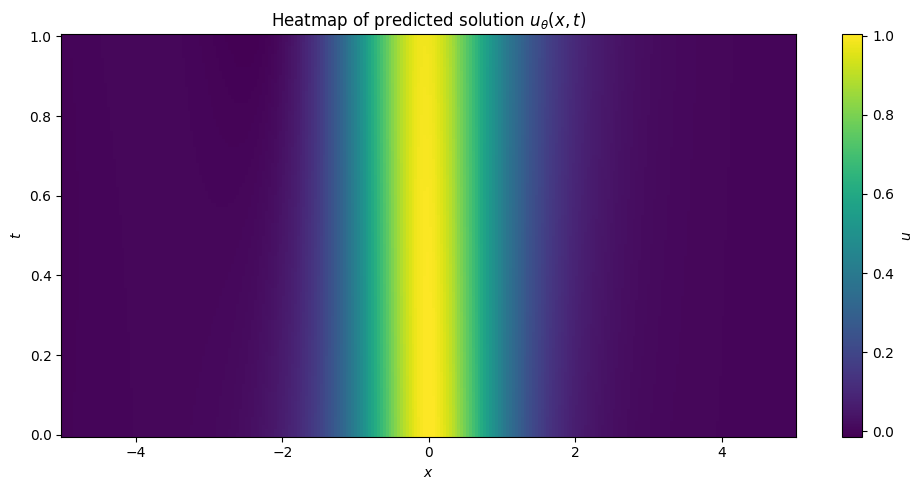

In [2]:
# ===============================================
# 7. Mapa de calor de u(x,t)
# ===============================================
# Crear malla de evaluación
x_vals = np.linspace(-5, 5, 256)
t_vals = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_vals, t_vals)

x_eval = torch.tensor(X.flatten(), dtype=torch.float32).view(-1, 1).to(device)
t_eval = torch.tensor(T.flatten(), dtype=torch.float32).view(-1, 1).to(device)

# Evaluar red en todo el dominio
with torch.no_grad():
    u_eval = model(x_eval, t_eval).cpu().numpy()

# Convertir a matriz para graficar
U = u_eval.reshape(T.shape)

# Graficar mapa de calor
plt.figure(figsize=(10, 5))
plt.pcolormesh(X, T, U, shading='auto', cmap='viridis')
plt.xlabel('$x$')
plt.ylabel('$t$')
plt.title('Heatmap of predicted solution $u_\\theta(x, t)$')
plt.colorbar(label='$u$')
plt.tight_layout()
plt.show()


In [4]:
# ===============================================
# 8. Solver espectral de referencia para gKdV
# ===============================================
from numpy.fft import fft, ifft, fftfreq

def solve_fourier_gkdv(x, u0, dt, nt, alpha=1.0, nu=3.0, beta=0.1):
    N = len(x)
    dx = x[1] - x[0]
    k = fftfreq(N, d=dx) * 2 * np.pi
    ik3 = (1j * k) ** 3

    u = u0.copy()
    sol = [u.copy()]

    for _ in range(nt):
        # medio paso lineal (Fourier)
        u_hat = fft(u)
        u_hat = u_hat * np.exp(-0.5 * dt * beta * ik3)
        u = np.real(ifft(u_hat))

        # paso completo no lineal (espacio físico)
        u = u - dt * alpha * u ** nu * np.gradient(u, dx)

        # medio paso lineal
        u_hat = fft(u)
        u_hat = u_hat * np.exp(-0.5 * dt * beta * ik3)
        u = np.real(ifft(u_hat))

        sol.append(u.copy())

    return np.array(sol)

# Datos de referencia
x_ref = np.linspace(-5, 5, 256)
u0_ref = initial_condition(x_ref)
dt = 0.01
nt = 100

# Ejecutar solver espectral
u_ref = solve_fourier_gkdv(x_ref, u0_ref, dt, nt, alpha, nu, beta)
t_ref = np.linspace(0, nt * dt, nt + 1)


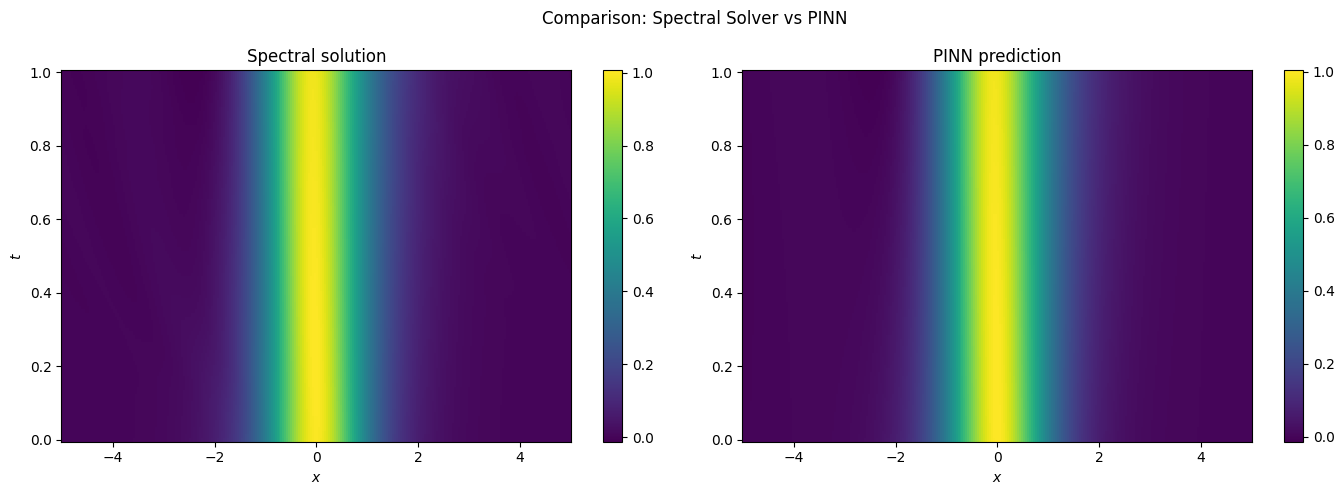

In [5]:
# ===============================================
# 9. Comparación de PINN vs Solver espectral
# ===============================================
from matplotlib import gridspec

# Evaluar PINN en mismos puntos (x_ref, t_ref)
X_ref, T_ref = np.meshgrid(x_ref, t_ref)
x_test = torch.tensor(X_ref.flatten(), dtype=torch.float32).view(-1, 1).to(device)
t_test = torch.tensor(T_ref.flatten(), dtype=torch.float32).view(-1, 1).to(device)

with torch.no_grad():
    u_pinn = model(x_test, t_test).cpu().numpy().reshape(T_ref.shape)

# Mapa de calor lado a lado
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2)

ax1 = fig.add_subplot(gs[0, 0])
pcm1 = ax1.pcolormesh(X_ref, T_ref, u_ref, shading='auto', cmap='viridis')
fig.colorbar(pcm1, ax=ax1)
ax1.set_title('Spectral solution')
ax1.set_xlabel('$x$')
ax1.set_ylabel('$t$')

ax2 = fig.add_subplot(gs[0, 1])
pcm2 = ax2.pcolormesh(X_ref, T_ref, u_pinn, shading='auto', cmap='viridis')
fig.colorbar(pcm2, ax=ax2)
ax2.set_title('PINN prediction')
ax2.set_xlabel('$x$')
ax2.set_ylabel('$t$')

plt.suptitle('Comparison: Spectral Solver vs PINN')
plt.tight_layout()
plt.show()


In [6]:
# ===============================================
# 10. Error L2 relativo promedio
# ===============================================
error_L2 = np.linalg.norm(u_ref - u_pinn) / np.linalg.norm(u_ref)
print(f"Relative L2 error: {error_L2:.2e}")


Relative L2 error: 7.55e-03


In [7]:
# === 0. libs & device ===
import numpy as np, torch, torch.nn as nn
from numpy.fft import fft, ifft, fftfreq

dev = 'cuda' if torch.cuda.is_available() else 'cpu'

# === 1. Fourier solver ===
def fourier_step(u, dt, beta_x, k):
    """One Strang split step for u_t + β(x) u_xxx."""
    # linear dispersion in Fourier space
    u_hat = fft(u)
    u_hat *= np.exp(-1j * (k**3) * beta_x * dt)
    return np.real(ifft(u_hat))

# === 2. PINN ===
class MLP(nn.Module):
    def __init__(self, layers):
        super().__init__()
        acts = []
        for a,b in zip(layers, layers[1:-1]):
            acts += [nn.Linear(a,b), nn.Tanh()]
        acts += [nn.Linear(layers[-2], layers[-1])]
        self.net = nn.Sequential(*acts)

    def forward(self, x, t):     # x,t : (N,1)
        return self.net(torch.cat([x,t],1))

def residual(model, x, t, alpha, nu, beta):
    x.requires_grad_(True); t.requires_grad_(True)
    u = model(x,t)
    u_x  = torch.autograd.grad(u,x,torch.ones_like(u),True,True)[0]
    u_t  = torch.autograd.grad(u,t,torch.ones_like(u),True,True)[0]
    u_xx = torch.autograd.grad(u_x,x,torch.ones_like(u),True,True)[0]
    u_xxx= torch.autograd.grad(u_xx,x,torch.ones_like(u),True,True)[0]
    return u_t + alpha*u**nu*u_x + beta(x)*u_xxx

# === 3. Driver ===
def adaptive_solver(u0, beta_fn, params):
    """Hybrid loop returning time snapshots."""
    # unpack params .................................................
    dt_F   = params['dt_F']        # Fourier step
    dt_P   = params['dt_P']        # PINN collocation step
    Tmax   = params['Tmax']
    alpha,nu = params['alpha'],params['nu']
    kcut,thresh,bthresh = params['kcut'],params['thresh'],params['bthresh']

    # spectral grid .................................................
    N = len(u0); dx = 2*np.pi/N
    k = fftfreq(N, d=dx)*2*np.pi
    u = u0.copy(); t = 0.0
    store = [(t,u.copy())]

    while t < Tmax:
        # == S‑stage ==
        βx = beta_fn(0)            # assume slowly varying in t
        u = fourier_step(u, dt_F, βx, k)
        t += dt_F

        # indicator .................................................
        highE = np.sum(np.abs(fft(u)[np.abs(k)>kcut])**2)
        totE  = np.sum(np.abs(fft(u))**2)
        sigma = highE/totE; gamma = np.max(np.abs(beta_fn.derivative()))
        if sigma>thresh or gamma>bthresh:
            # == P‑stage ==
            model = MLP([2,128,128,1]).to(dev)
            # warm‑start ............................................
            xgrid = np.linspace(-np.pi,np.pi,N,endpoint=False)
            x_torch = torch.tensor(xgrid, dtype=torch.float32, device=dev).view(-1,1)
            t0      = torch.full_like(x_torch, t)
            with torch.no_grad():
                model.net[-1].bias.data[:] = torch.tensor(u, device=dev)
            opt = torch.optim.Adam(model.parameters(), 1e-3)

            for _ in range(params['pinn_epochs']):
                opt.zero_grad()
                res = residual(model, x_torch, t0, alpha, nu, beta_fn)
                loss = (res**2).mean()
                loss.backward(); opt.step()
                if loss.item()<params['tol']: break

            # push solution back ....................................
            with torch.no_grad():
                u = model(x_torch, torch.full_like(x_torch,t)).cpu().numpy().ravel()

        store.append((t,u.copy()))
    return store


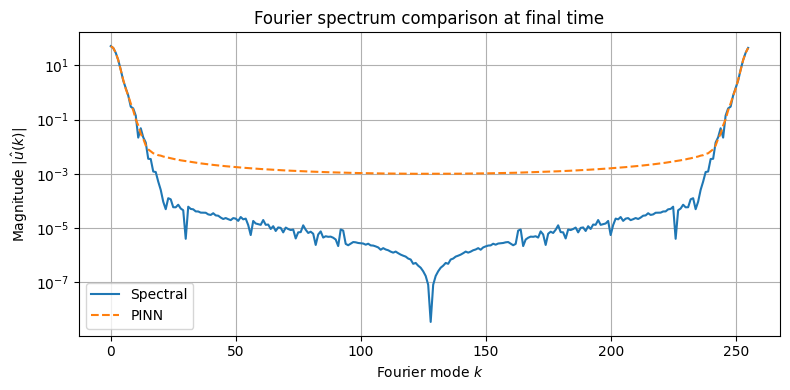

In [8]:
from numpy.fft import fft

# FFT al tiempo final
u_hat_ref = np.abs(fft(u_ref[-1]))
u_hat_pinn = np.abs(fft(u_pinn[-1]))

plt.figure(figsize=(8,4))
plt.semilogy(u_hat_ref, label='Spectral')
plt.semilogy(u_hat_pinn, '--', label='PINN')
plt.xlabel('Fourier mode $k$')
plt.ylabel('Magnitude $|\\hat{u}(k)|$')
plt.title('Fourier spectrum comparison at final time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
# Energía espectral total del solver de referencia
energy_ref = np.sum(np.abs(fft(u_ref[-1]))**2)

# Energía espectral total del PINN
energy_pinn = np.sum(np.abs(fft(u_pinn[-1]))**2)

# Error relativo
energy_error = np.abs(energy_pinn - energy_ref) / energy_ref

print(f"Spectral energy (Reference): {energy_ref:.6f}")
print(f"Spectral energy (PINN):      {energy_pinn:.6f}")
print(f"Relative energy error:       {energy_error:.2e}")


Spectral energy (Reference): 8713.227484
Spectral energy (PINN):      8678.133789
Relative energy error:       4.03e-03


Epoch  500 | Hybrid loss: 2.94e-08
Epoch 1000 | Hybrid loss: 9.95e-09
Epoch 1500 | Hybrid loss: 5.44e-09
Epoch 2000 | Hybrid loss: 3.58e-09
Epoch 2500 | Hybrid loss: 2.47e-09
Epoch 3000 | Hybrid loss: 1.71e-09


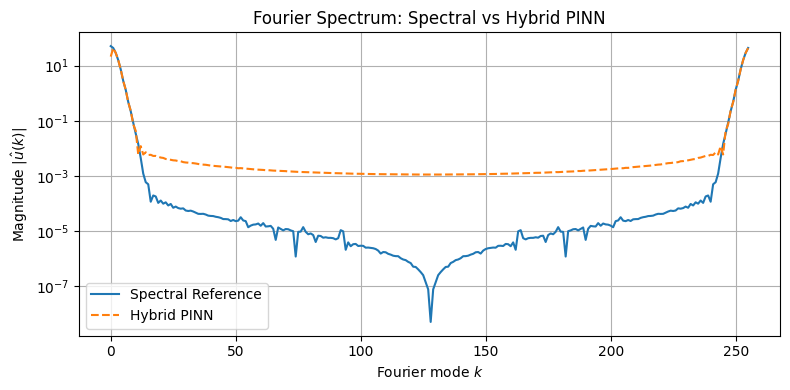

In [10]:
# ===============================================
# 0. Setup: imports y dominio
# ===============================================
import torch, torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, fftfreq

# Dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dominio
x_vals = np.linspace(-5, 5, 256)
t_vals = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_vals, t_vals)
dx = x_vals[1] - x_vals[0]

x_tensor = torch.tensor(X.flatten(), dtype=torch.float32).view(-1, 1).to(device)
t_tensor = torch.tensor(T.flatten(), dtype=torch.float32).view(-1, 1).to(device)

# ===============================================
# 1. Solver espectral: referencia
# ===============================================
def initial_condition(x):
    return 1 / np.cosh(x)**2

def solve_fourier_gkdv(x, u0, dt, nt, alpha=1.0, nu=1.0, beta=0.1):
    N = len(x)
    dx = x[1] - x[0]
    k = fftfreq(N, d=dx) * 2 * np.pi
    ik3 = (1j * k)**3
    u = u0.copy()
    sol = [u.copy()]
    for _ in range(nt):
        u_hat = fft(u) * np.exp(-0.5 * dt * beta * ik3)
        u = np.real(np.fft.ifft(u_hat))
        u -= dt * alpha * u**nu * np.gradient(u, dx)
        u_hat = fft(u) * np.exp(-0.5 * dt * beta * ik3)
        u = np.real(np.fft.ifft(u_hat))
        sol.append(u.copy())
    return np.array(sol)

u0_ref = initial_condition(x_vals)
u_ref = solve_fourier_gkdv(x_vals, u0_ref, dt=0.01, nt=99)

# ===============================================
# 2. Red neuronal: PINN para residuo
# ===============================================
class MLP(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(len(layers)-2):
            self.net.append(nn.Linear(layers[i], layers[i+1]))
            self.net.append(nn.Tanh())
        self.net.append(nn.Linear(layers[-2], layers[-1]))

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

model = MLP([2, 128, 128, 128, 1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ===============================================
# 3. Entrenamiento híbrido con precondicionamiento
# ===============================================
alpha, nu, beta = 1.0, 3.0, 0.1
x_r = x_tensor
t_r = t_tensor

# u_ref interpolado en malla
u_ref_tensor = torch.tensor(u_ref.flatten(), dtype=torch.float32).view(-1, 1).to(device)

# Residuo de la corrección
def gkdv_residual_correction(model, x, t, u_ref_val):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u_corr = model(x, t)
    u_total = u_corr + u_ref_val
    u_x = torch.autograd.grad(u_total, x, torch.ones_like(u_total), retain_graph=True, create_graph=True)[0]
    u_t = torch.autograd.grad(u_total, t, torch.ones_like(u_total), retain_graph=True, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_total), retain_graph=True, create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x, torch.ones_like(u_total), retain_graph=True, create_graph=True)[0]
    return u_t + alpha * u_total**nu * u_x + beta * u_xxx

# Entrenamiento
for epoch in range(1, 3001):
    optimizer.zero_grad()
    res = gkdv_residual_correction(model, x_r, t_r, u_ref_tensor)
    loss = (res**2).mean()
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Hybrid loss: {loss.item():.2e}")

# ===============================================
# 4. Comparación de espectros
# ===============================================
from numpy.fft import fft

# Solución total
with torch.no_grad():
    u_corr = model(x_tensor, t_tensor).cpu().numpy().flatten()
    u_total = u_corr + u_ref.flatten()

# FFT
u_hat_ref = np.abs(fft(u_ref[-1]))
u_hat_hybrid = np.abs(fft(u_total.reshape(u_ref.shape)[-1]))

plt.figure(figsize=(8,4))
plt.semilogy(u_hat_ref, label='Spectral Reference')
plt.semilogy(u_hat_hybrid, '--', label='Hybrid PINN')
plt.xlabel('Fourier mode $k$')
plt.ylabel('Magnitude $|\hat{u}(k)|$')
plt.title('Fourier Spectrum: Spectral vs Hybrid PINN')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('hybrid_fourier_comparison.png')
plt.show()


In [11]:
# Error L2 de la solución híbrida
u_ref_flat = u_ref.flatten()
error_L2_hybrid = np.linalg.norm(u_total - u_ref_flat) / np.linalg.norm(u_ref_flat)
print(f"Hybrid model relative L2 error: {error_L2_hybrid:.2e}")


Hybrid model relative L2 error: 3.19e-01


In [12]:
energy_ref = np.sum(np.abs(fft(u_ref[-1]))**2)
energy_hybrid = np.sum(np.abs(fft(u_total.reshape(u_ref.shape)[-1]))**2)


Usando dispositivo: cuda
Epoch  500 | Loss PDE: 1.044e-03 | Loss IC: 8.218e-03
Epoch 1000 | Loss PDE: 9.411e-04 | Loss IC: 7.077e-03
Epoch 1500 | Loss PDE: 8.422e-04 | Loss IC: 6.720e-03
Epoch 2000 | Loss PDE: 8.138e-04 | Loss IC: 6.440e-03
Epoch 2500 | Loss PDE: 1.096e-03 | Loss IC: 7.195e-03
Epoch 3000 | Loss PDE: 8.019e-04 | Loss IC: 6.287e-03
Epoch 3500 | Loss PDE: 7.986e-04 | Loss IC: 6.200e-03
Epoch 4000 | Loss PDE: 7.978e-04 | Loss IC: 6.161e-03
Epoch 4500 | Loss PDE: 7.986e-04 | Loss IC: 6.131e-03
Epoch 5000 | Loss PDE: 7.966e-04 | Loss IC: 6.091e-03


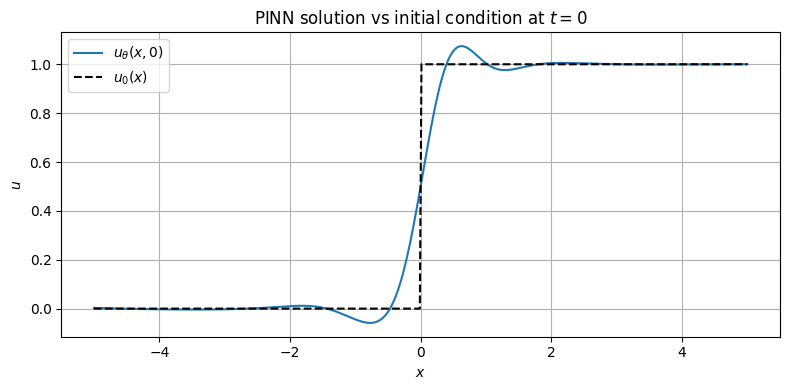

In [13]:
# ===============================================
# 1. Imports y configuración
# ===============================================
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# ===============================================
# 2. Red neuronal (PINN)
# ===============================================
class MLP(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(len(layers)-2):
            self.net.append(nn.Linear(layers[i], layers[i+1]))
            self.net.append(nn.Tanh())
        self.net.append(nn.Linear(layers[-2], layers[-1]))

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

# ===============================================
# 3. Condición inicial y dominio
# ===============================================
def initial_condition(x):
    return np.where(x > 0.0, 1.0, 0.0)  # Función de paso


# Dominio de entrenamiento
x_vals = np.linspace(-5, 5, 256)
t_vals = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_vals, t_vals)

x_r = torch.tensor(X.flatten(), dtype=torch.float32).view(-1, 1).to(device)
t_r = torch.tensor(T.flatten(), dtype=torch.float32).view(-1, 1).to(device)

# Datos para condición inicial
x_ic = torch.tensor(x_vals, dtype=torch.float32).view(-1, 1).to(device)
t_ic = torch.zeros_like(x_ic).to(device)
u0 = torch.tensor(initial_condition(x_vals), dtype=torch.float32).view(-1, 1).to(device)

# ===============================================
# 4. Residuo físico de la gKdV
# ===============================================
alpha, nu, beta = 1.0, 1.0, 0.1  # parámetros de la ecuación

def gkdv_residual(model, x, t, alpha, nu, beta):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    return u_t + alpha * u**nu * u_x + beta * u_xxx

# ===============================================
# 5. Entrenamiento
# ===============================================
model = MLP([2, 128, 128, 128, 1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1, 5001):
    optimizer.zero_grad()

    # Residuo de la PDE
    res = gkdv_residual(model, x_r, t_r, alpha, nu, beta)
    loss_pde = (res**2).mean()

    # Condición inicial
    u_pred0 = model(x_ic, t_ic)
    loss_ic = ((u_pred0 - u0)**2).mean()

    # Total loss
    loss = loss_pde + loss_ic
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss PDE: {loss_pde.item():.3e} | Loss IC: {loss_ic.item():.3e}")

# ===============================================
# 6. Visualización de la solución en t = 0
# ===============================================
x_plot = np.linspace(-5, 5, 400)
t_plot = np.zeros_like(x_plot)

x_tensor = torch.tensor(x_plot, dtype=torch.float32).view(-1, 1).to(device)
t_tensor = torch.tensor(t_plot, dtype=torch.float32).view(-1, 1).to(device)

with torch.no_grad():
    u_pred = model(x_tensor, t_tensor).cpu().numpy()

plt.figure(figsize=(8, 4))
plt.plot(x_plot, u_pred, label='$u_\\theta(x, 0)$')
plt.plot(x_plot, initial_condition(x_plot), 'k--', label='$u_0(x)$')
plt.xlabel('$x$')
plt.ylabel('$u$')
plt.title('PINN solution vs initial condition at $t=0$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


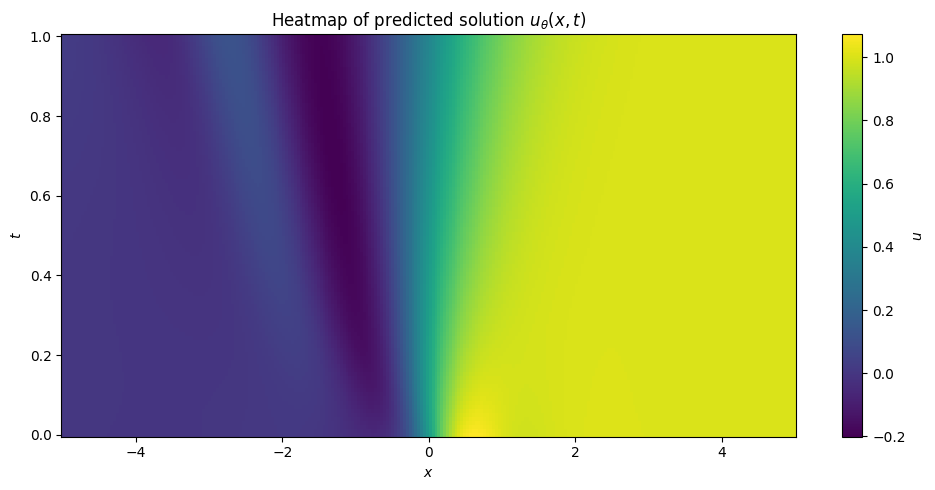

In [ ]:
# ===============================================
# 7. Mapa de calor de u(x,t)
# ===============================================
# Crear malla de evaluación
x_vals = np.linspace(-5, 5, 256)
t_vals = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_vals, t_vals)

x_eval = torch.tensor(X.flatten(), dtype=torch.float32).view(-1, 1).to(device)
t_eval = torch.tensor(T.flatten(), dtype=torch.float32).view(-1, 1).to(device)

# Evaluar red en todo el dominio
with torch.no_grad():
    u_eval = model(x_eval, t_eval).cpu().numpy()

# Convertir a matriz para graficar
U = u_eval.reshape(T.shape)

# Graficar mapa de calor
plt.figure(figsize=(10, 5))
plt.pcolormesh(X, T, U, shading='auto', cmap='viridis')
plt.xlabel('$x$')
plt.ylabel('$t$')
plt.title('Heatmap of predicted solution $u_\\theta(x, t)$')
plt.colorbar(label='$u$')
plt.tight_layout()
plt.show()


In [ ]:
# ===============================================
# 8. Solver espectral de referencia para gKdV
# ===============================================
from numpy.fft import fft, ifft, fftfreq

def solve_fourier_gkdv(x, u0, dt, nt, alpha=1.0, nu=1.0, beta=0.1):
    N = len(x)
    dx = x[1] - x[0]
    k = fftfreq(N, d=dx) * 2 * np.pi
    ik3 = (1j * k) ** 3

    u = u0.copy()
    sol = [u.copy()]

    for _ in range(nt):
        # medio paso lineal (Fourier)
        u_hat = fft(u)
        u_hat = u_hat * np.exp(-0.5 * dt * beta * ik3)
        u = np.real(ifft(u_hat))

        # paso completo no lineal (espacio físico)
        u = u - dt * alpha * u ** nu * np.gradient(u, dx)

        # medio paso lineal
        u_hat = fft(u)
        u_hat = u_hat * np.exp(-0.5 * dt * beta * ik3)
        u = np.real(ifft(u_hat))

        sol.append(u.copy())

    return np.array(sol)

# Datos de referencia
x_ref = np.linspace(-5, 5, 256)
u0_ref = initial_condition(x_ref)
dt = 0.01
nt = 100

# Ejecutar solver espectral
u_ref = solve_fourier_gkdv(x_ref, u0_ref, dt, nt, alpha, nu, beta)
t_ref = np.linspace(0, nt * dt, nt + 1)


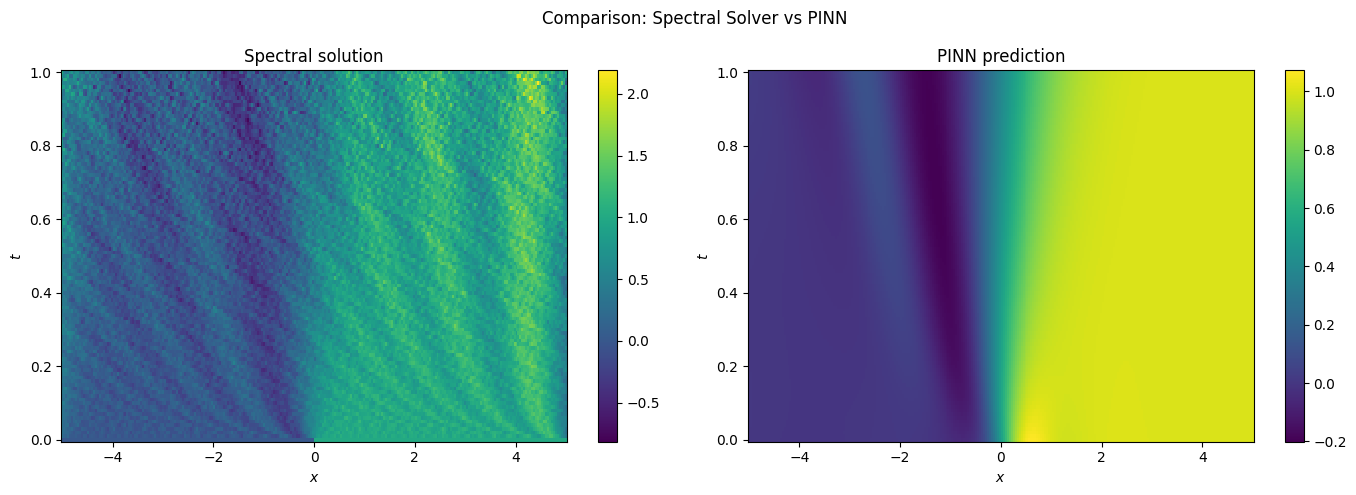

In [ ]:
# ===============================================
# 9. Comparación de PINN vs Solver espectral
# ===============================================
from matplotlib import gridspec

# Evaluar PINN en mismos puntos (x_ref, t_ref)
X_ref, T_ref = np.meshgrid(x_ref, t_ref)
x_test = torch.tensor(X_ref.flatten(), dtype=torch.float32).view(-1, 1).to(device)
t_test = torch.tensor(T_ref.flatten(), dtype=torch.float32).view(-1, 1).to(device)

with torch.no_grad():
    u_pinn = model(x_test, t_test).cpu().numpy().reshape(T_ref.shape)

# Mapa de calor lado a lado
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2)

ax1 = fig.add_subplot(gs[0, 0])
pcm1 = ax1.pcolormesh(X_ref, T_ref, u_ref, shading='auto', cmap='viridis')
fig.colorbar(pcm1, ax=ax1)
ax1.set_title('Spectral solution')
ax1.set_xlabel('$x$')
ax1.set_ylabel('$t$')

ax2 = fig.add_subplot(gs[0, 1])
pcm2 = ax2.pcolormesh(X_ref, T_ref, u_pinn, shading='auto', cmap='viridis')
fig.colorbar(pcm2, ax=ax2)
ax2.set_title('PINN prediction')
ax2.set_xlabel('$x$')
ax2.set_ylabel('$t$')

plt.suptitle('Comparison: Spectral Solver vs PINN')
plt.tight_layout()
plt.show()


In [ ]:
# ===============================================
# 10. Error L2 relativo promedio
# ===============================================
error_L2 = np.linalg.norm(u_ref - u_pinn) / np.linalg.norm(u_ref)
print(f"Relative L2 error: {error_L2:.2e}")


Relative L2 error: 2.99e-01


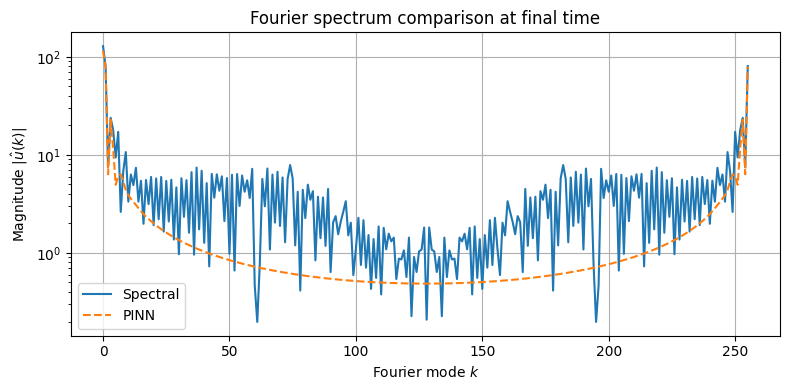

In [ ]:
from numpy.fft import fft

# FFT al tiempo final
u_hat_ref = np.abs(fft(u_ref[-1]))
u_hat_pinn = np.abs(fft(u_pinn[-1]))

plt.figure(figsize=(8,4))
plt.semilogy(u_hat_ref, label='Spectral')
plt.semilogy(u_hat_pinn, '--', label='PINN')
plt.xlabel('Fourier mode $k$')
plt.ylabel('Magnitude $|\\hat{u}(k)|$')
plt.title('Fourier spectrum comparison at final time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:

pip install torch numpy matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [ ]:
import numpy as np

class BetaX:
    def __init__(self, L=2*np.pi):
        self.L = L
    def __call__(self, x):
        # 0.1 · (1 + 0.5 sin x)
        return 0.1 * (1.0 + 0.5 * np.sin(x))
    def derivative(self):
        # ||β'(x)||∞  ≈  0.05
        return 0.05


In [ ]:
N   = 512               # puntos espaciales
L   = 2*np.pi           # dominio [-π, π]
x   = np.linspace(-np.pi, np.pi, N, endpoint=False)

def u0_profile(x):
    return 1.0 / np.cosh(x)**2        # solitón estándar

u0  = u0_profile(x)                  # vector NumPy


In [ ]:
params = dict(
    # pasos de tiempo
    dt_F = 1e-3,           # Fourier (rápido)
    dt_P = 5e-3,           # sólo se usa para collocation en PINN
    Tmax = 1.0,            # tiempo final
    # coeficientes gKdV
    alpha = 1.0,
    nu    = 1.0,
    # umbrales de conmutación
    kcut   = N//4,         # frecuencia de corte
    thresh = 1e-3,         # σ_max
    bthresh= 0.06,         # γ_max (> 0.05 para que dispare)
    # entrenamiento PINN
    pinn_epochs = 1000,
    tol         = 1e-4
)


In [ ]:
def adaptive_solver(u0, beta_fn, params):
    """
    Hybrid spectral–PINN solver for variable‑beta gKdV.
    Returns a list of tuples (t, u(x,t)).
    """
    # ------------ desempaquetado de parámetros ------------
    dt_F   = params['dt_F']        # paso Fourier
    Tmax   = params['Tmax']
    alpha, nu = params['alpha'], params['nu']
    kcut, thresh, bthresh = params['kcut'], params['thresh'], params['bthresh']
    # --- parámetros PINN
    pinn_epochs = params['pinn_epochs']
    tol         = params['tol']

    # ------------ rejilla espectral ------------
    N  = len(u0)
    dx = 2*np.pi / N
    k  = fftfreq(N, d=dx) * 2*np.pi

    u  = u0.copy()
    t  = 0.0
    history = [(t, u.copy())]

    while t < Tmax:
        # === ETAPA ESPECTRAL ==============================
        beta_val = beta_fn(0)      # β(x) ~ constante en este paso
        u = fourier_step(u, dt_F, beta_val, k)
        t += dt_F

        # --- criterio de conmutación ---------------------
        highE = np.sum(np.abs(fft(u)[np.abs(k) > kcut])**2)
        totE  = np.sum(np.abs(fft(u))**2)
        sigma = highE / totE
        gamma = beta_fn.derivative()

        if sigma > thresh or gamma > bthresh:
            # === ETAPA PINN ==============================
            device = 'cuda' if torch.cuda.is_available() else 'cpu'
            model = MLP([2, 128, 128, 1]).to(device)

            # rejilla torch
            xgrid = np.linspace(-np.pi, np.pi, N, endpoint=False)
            x_t   = torch.tensor(xgrid, dtype=torch.float32, device=device).view(-1,1)
            t0_t  = torch.full_like(x_t, t)

            # warm‑start simple: ajustar bias final al perfil actual
            with torch.no_grad():
                model.net[-1].bias.data = torch.tensor(u, device=device)

            opt = torch.optim.Adam(model.parameters(), lr=1e-3)

            for _ in range(pinn_epochs):
                opt.zero_grad()
                res = residual(model, x_t, t0_t, alpha, nu, beta_fn)
                loss = (res**2).mean()
                if loss.item() < tol:
                    break
                loss.backward()
                opt.step()

            with torch.no_grad():
                u = model(x_t, t0_t).cpu().numpy().ravel()

        history.append((t, u.copy()))

    return history


Usando dispositivo: cuda


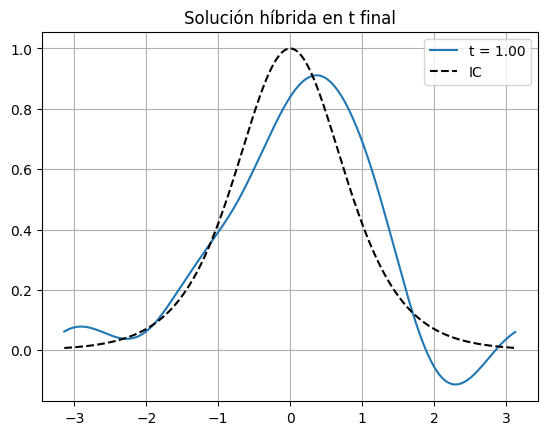

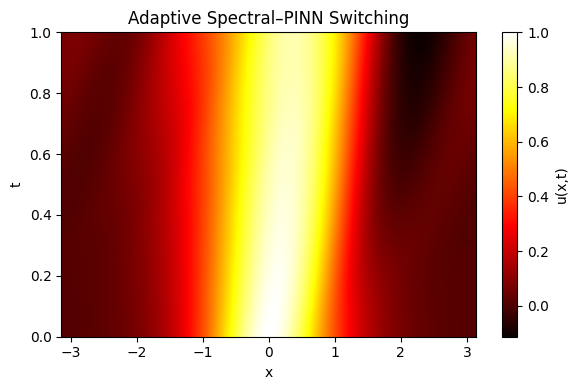

In [ ]:
# ============================================
# 1. LIBRERÍAS
# ============================================
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftfreq

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Usando dispositivo:", device)

# ============================================
# 2. SOLVER FOURIER
# ============================================
def fourier_step(u, dt, beta_val, k):
    u_hat = fft(u)
    u_hat *= np.exp(-1j * (k**3) * beta_val * dt)
    return np.real(ifft(u_hat))

# ============================================
# 3. RED PINN + RESIDUAL
# ============================================
class MLP(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential()
        for i in range(len(layers) - 2):
            self.net.append(nn.Linear(layers[i], layers[i + 1]))
            self.net.append(nn.Tanh())
        self.net.append(nn.Linear(layers[-2], layers[-1]))

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

def residual(model, x, t, alpha, nu, beta_fn):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    return u_t + alpha * u**nu * u_x + beta_fn(x) * u_xxx

# ============================================
# 4. BETA(x) VARIABLE
# ============================================
class BetaX:
    def __init__(self, L=2*np.pi):
        self.L = L
    def __call__(self, x):
        return 0.1 * (1.0 + 0.5 * np.sin(x))
    def derivative(self):
        return 0.05

# ============================================
# 5. ADAPTIVE SOLVER
# ============================================
def adaptive_solver(u0, beta_fn, params):
    dt_F = params['dt_F']
    Tmax = params['Tmax']
    alpha, nu = params['alpha'], params['nu']
    kcut, thresh, bthresh = params['kcut'], params['thresh'], params['bthresh']
    pinn_epochs = params['pinn_epochs']
    tol = params['tol']

    N = len(u0)
    dx = 2*np.pi / N
    k = fftfreq(N, d=dx) * 2*np.pi

    u = u0.copy()
    t = 0.0
    history = [(t, u.copy())]

    while t < Tmax:
        beta_val = beta_fn(0)
        u = fourier_step(u, dt_F, beta_val, k)
        t += dt_F

        highE = np.sum(np.abs(fft(u)[np.abs(k) > kcut])**2)
        totE  = np.sum(np.abs(fft(u))**2)
        sigma = highE / totE
        gamma = beta_fn.derivative()

        if sigma > thresh or gamma > bthresh:
            model = MLP([2, 128, 128, 1]).to(device)

            xgrid = np.linspace(-np.pi, np.pi, N, endpoint=False)
            x_t = torch.tensor(xgrid, dtype=torch.float32, device=device).view(-1, 1)
            t0_t = torch.full_like(x_t, t)

            with torch.no_grad():
                model.net[-1].bias.data = torch.tensor(u, device=device)

            opt = torch.optim.Adam(model.parameters(), lr=1e-3)
            for _ in range(pinn_epochs):
                opt.zero_grad()
                res = residual(model, x_t, t0_t, alpha, nu, beta_fn)
                loss = (res**2).mean()
                if loss.item() < tol:
                    break
                loss.backward()
                opt.step()

            with torch.no_grad():
                u = model(x_t, t0_t).cpu().numpy().ravel()

        history.append((t, u.copy()))
    return history

# ============================================
# 6. INICIALIZACIÓN
# ============================================
N = 512
x = np.linspace(-np.pi, np.pi, N, endpoint=False)

def initial_condition(x):
    return 1.0 / np.cosh(x)**2

u0 = initial_condition(x)
beta_fn = BetaX()

params = dict(
    dt_F = 1e-3,
    Tmax = 1.0,
    alpha = 1.0,
    nu = 1.0,
    kcut = N // 4,
    thresh = 1e-3,
    bthresh = 0.06,
    pinn_epochs = 1000,
    tol = 1e-4
)

# ============================================
# 7. EJECUTAR
# ============================================
history = adaptive_solver(u0, beta_fn, params)

# ============================================
# 8. VISUALIZACIÓN
# ============================================
# Curva en t final
t_final, u_final = history[-1]
plt.plot(x, u_final, label=f't = {t_final:.2f}')
plt.plot(x, u0, '--k', label='IC')
plt.legend(); plt.grid(); plt.title('Solución híbrida en t final')
plt.show()

# Mapa de calor u(x,t)
T_vals = [t for t, _ in history]
U_vals = np.array([u for _, u in history])

plt.figure(figsize=(6, 4))
plt.imshow(U_vals, extent=[-np.pi, np.pi, 0, params['Tmax']],
           aspect='auto', origin='lower', cmap='hot')
plt.colorbar(label='u(x,t)')
plt.xlabel('x'); plt.ylabel('t')
plt.title('Adaptive Spectral–PINN Switching')
plt.tight_layout()
plt.show()


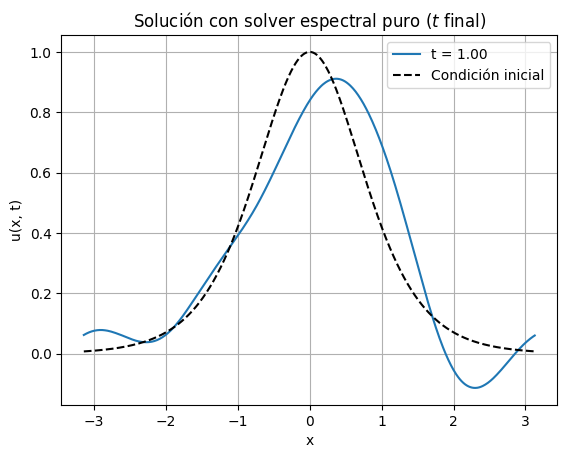

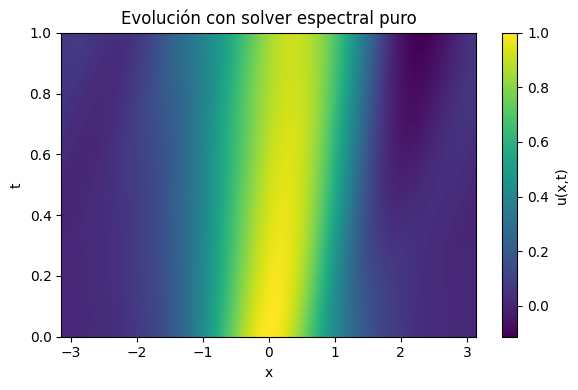

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftfreq

# --------------------------------------------
# 1. Parámetros y condición inicial
# --------------------------------------------
N = 512
x = np.linspace(-np.pi, np.pi, N, endpoint=False)

def initial_condition(x):
    return 1.0 / np.cosh(x)**2

u0 = initial_condition(x)

# --------------------------------------------
# 2. Función fourier_step
# --------------------------------------------
def fourier_step(u, dt, beta_val, k):
    u_hat = fft(u)
    u_hat *= np.exp(-1j * (k**3) * beta_val * dt)
    return np.real(ifft(u_hat))

# --------------------------------------------
# 3. Simulación pura con solver espectral
# --------------------------------------------
beta_const = 0.1          # coeficiente dispersivo constante
Tmax = 1.0
dt = 1e-3
steps = int(Tmax / dt)

dx = 2 * np.pi / N
k = fftfreq(N, d=dx) * 2 * np.pi

u = u0.copy()
history = [(0.0, u.copy())]

for i in range(steps):
    u = fourier_step(u, dt, beta_const, k)
    t = (i + 1) * dt
    history.append((t, u.copy()))

# --------------------------------------------
# 4. Visualización
# --------------------------------------------

# 4.1 Curva en t_final
t_final, u_final = history[-1]
plt.figure()
plt.plot(x, u_final, label=f't = {t_final:.2f}')
plt.plot(x, u0, '--k', label='Condición inicial')
plt.legend()
plt.grid()
plt.title('Solución con solver espectral puro ($t$ final)')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.show()

# 4.2 Mapa de calor de la evolución u(x,t)
T_vals = [t for t, _ in history]
U_vals = np.array([u for _, u in history])

plt.figure(figsize=(6, 4))
plt.imshow(U_vals, extent=[-np.pi, np.pi, 0, Tmax],
           aspect='auto', origin='lower')
plt.colorbar(label='u(x,t)')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Evolución con solver espectral puro')
plt.tight_layout()
plt.show()
